In [1]:
# 第3章｜技術指標機器學習策略：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1 lightgbm
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


# 技術指標機器學習策略

**對應影片**：第 3 章 單元 9、10「技術指標機器學習策略 Part 1、Part 2」

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| 大盤 15 分 K，指標期間動輒 120～960 根 K 棒 | 加權指數日 K，指標期間 5～120 天 |
| 預測下一根 K 棒漲跌，報酬用指數點數相加 | 預測「買進 0050、持有 10 天」會不會賺錢，用 `sim()` 回測（含交易成本） |
| 手寫幾十行重複的 `talib.STOCH(...)` | 用迴圈產生不同期間的指標 |

Part 1：做出技術指標特徵、訓練 LightGBM。Part 2：把預測變成交易策略並回測。

In [2]:
import pandas as pd
import talib
import finlab.ml.label as label
from finlab.backtest import sim
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

TRADE_STOCK = '0050'
ETF_TAX_RATIO = 0.001
HORIZON = 10               # 預測未來幾個交易日的報酬
TRAIN_END = '2015-12-31'
TEST_START = '2016-01-01'
RANDOM_STATE = 0

## Part 1：特徵與模型

### 1. 加權指數日 K

In [3]:
taiex = pd.DataFrame({
    field: data.get(f'taiex_total_index:{name}')['TAIEX']
    for field, name in [('open', '開盤指數'), ('high', '最高指數'), ('low', '最低指數'), ('close', '收盤指數')]
}).dropna()
taiex.tail()

,open,high,low,close
date,,,,
2018-12-24,9646.53,9658.95,9613.29,9639.70
2018-12-25,9559.70,9559.70,9479.06,9527.09
2018-12-26,9544.87,9591.91,9473.30,9478.99
2018-12-27,9555.01,9670.97,9555.01,9641.56
2018-12-28,9649.97,9727.41,9630.77,9727.41


### 2. 技術指標特徵

每個指標用多個期間計算。價格類的指標（均線、MACD）除以指數本身，變成「相對位置」，不同年代的指數高低才能比較。

In [4]:
PERIODS = [5, 10, 20, 60, 120]
STOCH_SMOOTHING = 3


def technical_features(ohlc: pd.DataFrame) -> pd.DataFrame:
    high, low, close = ohlc['high'], ohlc['low'], ohlc['close']
    features = {}
    for period in PERIODS:
        slowk, slowd = talib.STOCH(high, low, close, fastk_period=period,
                                   slowk_period=STOCH_SMOOTHING, slowd_period=STOCH_SMOOTHING)
        features[f'rsi_{period}'] = talib.RSI(close, timeperiod=period)
        features[f'k_{period}'] = slowk
        features[f'd_{period}'] = slowd
        features[f'willr_{period}'] = talib.WILLR(high, low, close, timeperiod=period)
        features[f'cci_{period}'] = talib.CCI(high, low, close, timeperiod=period)
        features[f'roc_{period}'] = talib.ROC(close, timeperiod=period)
        features[f'sma_bias_{period}'] = close / talib.SMA(close, timeperiod=period)
        features[f'wma_bias_{period}'] = close / talib.WMA(close, timeperiod=period)
        features[f'atr_ratio_{period}'] = talib.ATR(high, low, close, timeperiod=period) / close
    macd, macd_signal, macd_hist = talib.MACD(close)
    features['macd'] = macd / close
    features['macd_signal'] = macd_signal / close
    features['macd_hist'] = macd_hist / close
    return pd.DataFrame(features)


features = technical_features(taiex)
feature_names = list(features.columns)
print(f'{len(feature_names)} 個特徵')
features.dropna().tail()

48 個特徵


,rsi_5,k_5,d_5,willr_5,cci_5,roc_5,sma_bias_5,wma_bias_5,atr_ratio_5,rsi_10,...,d_120,willr_120,cci_120,roc_120,sma_bias_120,wma_bias_120,atr_ratio_120,macd,macd_signal,macd_hist
date,,,,,,,,,,,,,,,,,,,,,
2018-12-24,31.871170,32.013653,29.944886,-72.520087,-63.896277,-0.814091,0.995420,0.997586,0.008697,39.744008,...,15.484397,-86.612784,-94.343552,-9.132899,0.927574,0.952419,0.011725,-0.005757,-0.004553,-0.001205
2018-12-25,19.911093,25.507369,27.848700,-81.702160,-166.666667,-2.617955,0.989023,0.991300,0.010412,33.041424,...,13.483866,-92.920195,-106.456115,-11.130213,0.917616,0.942625,0.011905,-0.007050,-0.005095,-0.001955
2018-12-26,16.587581,16.159639,24.560220,-97.298837,-87.373242,-2.021082,0.988041,0.991586,0.010875,30.592835,...,11.295886,-95.614330,-105.132106,-11.879828,0.913921,0.939253,0.011970,-0.008374,-0.005771,-0.002602
2018-12-27,51.083271,35.373557,25.680188,-14.878333,42.106387,-0.362831,1.005723,1.006912,0.012535,45.703452,...,9.336181,-86.508603,-90.133070,-9.696502,0.930369,0.956506,0.011836,-0.007786,-0.006096,-0.001689
2018-12-28,61.573308,62.607610,38.046935,-0.000000,100.891393,0.842304,1.012961,1.010926,0.011927,51.853770,...,9.554064,-81.700049,-79.818360,-9.414549,0.939417,0.966030,0.011716,-0.006578,-0.006150,-0.000429


### 3. 答案：買進 0050、持有 10 天會不會賺錢

`label.return_percentage` 算出每一天「隔天買進 0050、持有 `HORIZON` 天」的報酬。0050 的資料從 2007 年開始，所以資料集也從那時開始。

In [5]:
def forward_return(dates: pd.DatetimeIndex, period: int) -> pd.Series:
    index = pd.MultiIndex.from_product([dates, [TRADE_STOCK]], names=['datetime', 'instrument'])
    return label.return_percentage(index, period=period).droplevel('instrument')


dataset = features.assign(future_return=forward_return(features.index, HORIZON)).dropna()
dataset['up'] = dataset['future_return'] > 0

train, test = dataset.loc[:TRAIN_END], dataset.loc[TEST_START:]
print(f'訓練 {train.index[0]:%Y-%m} ~ {train.index[-1]:%Y-%m}，{len(train)} 天')
print(f'測試 {test.index[0]:%Y-%m} ~ {test.index[-1]:%Y-%m}，{len(test)} 天')
print(f'訓練期間上漲的比例：{train["up"].mean():.1%}')

訓練 2007-04 ~ 2015-12，2162 天
測試 2016-01 ~ 2018-12，726 天
訓練期間上漲的比例：54.3%


### 4. 訓練 LightGBM

In [6]:
model = LGBMClassifier(
    n_estimators=300, learning_rate=0.03, num_leaves=15, min_child_samples=50,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=RANDOM_STATE, verbose=-1,
)
model.fit(train[feature_names], train['up'])

train_probability = pd.Series(model.predict_proba(train[feature_names])[:, 1], index=train.index)
test_probability = pd.Series(model.predict_proba(test[feature_names])[:, 1], index=test.index)
print(f'訓練 AUC：{roc_auc_score(train["up"], train_probability):.3f}')
print(f'測試 AUC：{roc_auc_score(test["up"], test_probability):.3f}')

訓練 AUC：0.990
測試 AUC：0.514


訓練 AUC 遠高於測試 AUC，代表模型記住了很多訓練資料的細節（過度擬合）。這在金融資料很常見，所以回測一定要看測試期間。

### 5. 哪些特徵重要？

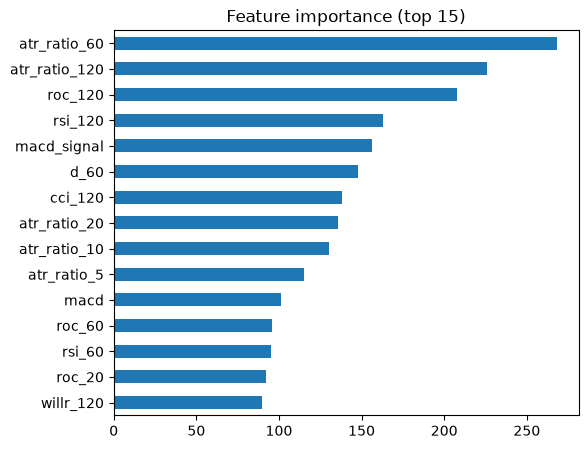

In [7]:
importance = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
importance.head(15).plot.barh(figsize=(6, 5), title='Feature importance (top 15)').invert_yaxis()

## Part 2：變成交易策略

### 6. 進出場規則（和影片相同）

- 機率高於「訓練期間機率的第 70 百分位」→ 出現買進訊號。門檻只用訓練期間決定，不偷看測試期間。
- 訊號出現後持有 `HORIZON` 天；期間內再出現訊號就延長。

In [8]:
SIGNAL_QUANTILE = 0.7

threshold = train_probability.quantile(SIGNAL_QUANTILE)
signal = test_probability > threshold
hold = signal.rolling(HORIZON, min_periods=1).max().astype(bool)

position = hold.to_frame(TRADE_STOCK)
print(f'機率門檻 {threshold:.3f}，測試期間有 {hold.mean():.0%} 的日子持有 0050')

機率門檻 0.769，測試期間有 46% 的日子持有 0050


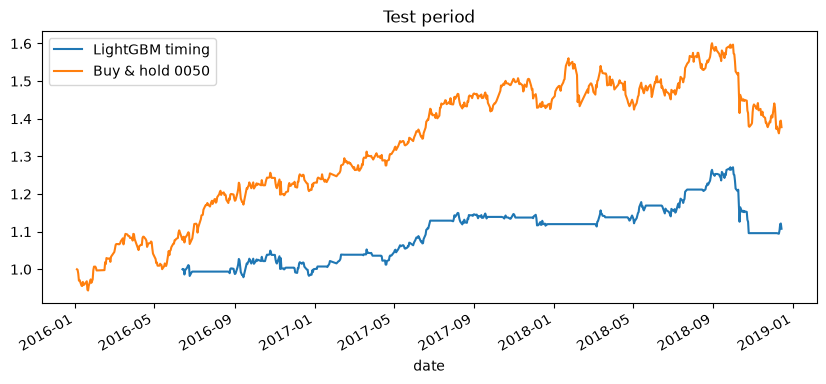

In [9]:
strategy = sim(position, name='LightGBM timing', tax_ratio=ETF_TAX_RATIO)
buy_and_hold = sim(position.notna(), name='Buy & hold 0050', tax_ratio=ETF_TAX_RATIO)

pd.DataFrame({'LightGBM timing': strategy.creturn, 'Buy & hold 0050': buy_and_hold.creturn}).plot(
    figsize=(10, 4), title='Test period');

In [10]:
pd.DataFrame({
    name: {key: report.get_stats()[key] for key in ['cagr', 'max_drawdown', 'daily_sharpe']}
    for name, report in [('LightGBM timing', strategy), ('Buy & hold 0050', buy_and_hold)]
}).T.style.format({'cagr': '{:.2%}', 'max_drawdown': '{:.2%}', 'daily_sharpe': '{:.2f}'})

,cagr,max_drawdown,daily_sharpe
LightGBM timing,4.17%,-13.90%,0.26
Buy & hold 0050,11.50%,-14.96%,0.72


試試看：改變 `HORIZON`、`SIGNAL_QUANTILE`，或在 `technical_features` 裡加入新的指標，測試期間的表現有沒有變好？
第 4 章會用同樣的特徵訓練神經網路。